# MLMC Sample Allocation Strategy Comparison

This notebook investigates different sample allocation strategies for the MLMC framework.

**Structure:**
1. **Part 1:** Effect of varying $C$ in the quadratic formula $M_\ell = C \cdot \dim(V)^2$
2. **Part 2:** True comparison of different allocation formulas (quadratic vs log vs linear vs sqrt)

**Key Questions:**
- Can we reduce samples without losing stability (condition number)?
- Can we reduce samples without losing accuracy?
- What's the computational trade-off?

**Required Files (same folder):**
- `config.py`
- `common.py`
- `mlmc_ot_estimator.py`
- `mlmc_flexible_allocation.py`
- `cost_metrics.py` (NEW - for hardware-independent metrics)

**Author:** Wadoud Bouslama  
**Date:** January 2026

## Setup

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
import time
import warnings
from typing import Callable, Dict, Tuple, List, Union
from dataclasses import dataclass
from contextlib import contextmanager

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# For nicer plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Setup complete!")

Setup complete!


## Benchmark Configuration

**Toggle threading control for fair comparison:**
- `DISABLE_THREADING = True`: Forces single-threaded execution (hardware-independent comparison)
- `DISABLE_THREADING = False`: Uses default parallelisation (faster, but hardware-dependent)

**Recommendation:** Set `True` when you want reproducible cost metrics across different machines.

In [9]:
# =============================================================================
# BENCHMARK CONFIGURATION - TOGGLE THREADING HERE
# =============================================================================

DISABLE_THREADING = True  # Set to True for fair, hardware-independent comparison

# =============================================================================

print("=" * 60)
print("BENCHMARK CONFIGURATION")
print("=" * 60)
print(f"  Threading disabled: {DISABLE_THREADING}")
if DISABLE_THREADING:
    print("  → Running single-threaded for fair comparison")
    print("  → Cost metrics will be hardware-independent")
else:
    print("  → Using default parallelisation (faster)")
    print("  → Wall-clock times may vary across machines")
print("=" * 60)

BENCHMARK CONFIGURATION
  Threading disabled: True
  → Running single-threaded for fair comparison
  → Cost metrics will be hardware-independent


In [10]:
# LOCAL IMPORTS - all files in the same folder
try:
    from config import DEFAULT_PARAMS, ProblemParameters
    print("✓ Imported config.py")
except ImportError as e:
    print(f"✗ Failed to import config.py: {e}")

try:
    from common import VolatilitySurfaceResult
    print("✓ Imported common.py")
except ImportError as e:
    print(f"✗ Failed to import common.py: {e}")

try:
    from mlmc_ot_estimator import (
        estimate_volatility_mlmc,
        tot_degree_poly,
        LevelStats
    )
    print("✓ Imported mlmc_ot_estimator.py")
except ImportError as e:
    print(f"✗ Failed to import mlmc_ot_estimator.py: {e}")

try:
    from mlmc_flexible_allocation import (
        estimate_volatility_mlmc_flexible,
        compute_samples_for_formula,
        ALLOCATION_FORMULAS,
        allocation_quadratic,
        allocation_log,
        allocation_linear,
        allocation_sqrt,
        allocation_log_squared
    )
    print("✓ Imported mlmc_flexible_allocation.py")
    print(f"  Available formulas: {list(ALLOCATION_FORMULAS.keys())}")
except ImportError as e:
    print(f"✗ Failed to import mlmc_flexible_allocation.py: {e}")

# Import cost metrics utilities
try:
    from cost_metrics import (
        CostMetrics,
        CostProfiler,
        single_threaded,
        count_function_calls,
        print_comparison_table
    )
    COST_METRICS_AVAILABLE = True
    print("✓ Imported cost_metrics.py")
    print("  Available: CostProfiler, single_threaded, count_function_calls")
except ImportError as e:
    COST_METRICS_AVAILABLE = False
    print(f"⚠ cost_metrics.py not found: {e}")
    print("  → Falling back to wall-clock timing only")
    print("  → Copy cost_metrics.py to this folder for hardware-independent metrics")

✓ Imported config.py
✓ Imported common.py
✓ Imported mlmc_ot_estimator.py
✓ Imported mlmc_flexible_allocation.py
  Available formulas: ['quadratic', 'log', 'linear', 'sqrt', 'log_squared']
✓ Imported cost_metrics.py
  Available: CostProfiler, single_threaded, count_function_calls


In [11]:
# Helper: Threading context manager
# This wraps the cost_metrics version or provides a no-op fallback

if COST_METRICS_AVAILABLE and DISABLE_THREADING:
    def get_thread_context():
        """Return single-threaded context manager."""
        return single_threaded()
    print("Threading context: single_threaded() from cost_metrics")
else:
    @contextmanager
    def _noop_context():
        yield
    def get_thread_context():
        """Return no-op context manager."""
        return _noop_context()
    print("Threading context: no-op (default parallelisation)")

Threading context: single_threaded() from cost_metrics


In [12]:
# =============================================================================
# STRESS TEST PARAMETER CONFIGURATIONS
# =============================================================================
# Use these to find the limits of the sample allocation strategies.
# Each configuration targets a different stress axis.
# =============================================================================

# -----------------------------------------------------------------------------
# 1. HIGH DIMENSION (more assets = harder regression)
# -----------------------------------------------------------------------------
HIGH_DIM_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.20, 0.18, 0.15, 0.22, 0.17, 0.19, 0.16, 0.21, 0.14, 0.20]),
    corr_matrix=np.eye(10) * 0.4 + np.ones((10, 10)) * 0.6,  # ρ = 0.6 off-diagonal
    P1=np.ones(10),
    x0=np.ones(10) * 100.0,
    T=0.5,
    K=1000.0,  # Strike scales with number of assets
    option_type="put",
    max_degree=3,
    h0=0.05,
    random_seed=42
)

# -----------------------------------------------------------------------------
# 2. HIGH VOLATILITY (larger diffusion = noisier regression)
# -----------------------------------------------------------------------------
HIGH_VOL_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.45, 0.40, 0.50]),  # ~2.5× default volatility
    corr_matrix=np.array([
        [1.0, 0.8, 0.3],
        [0.8, 1.0, 0.1],
        [0.3, 0.1, 1.0]
    ]),
    P1=np.array([1.0, 1.0, 1.0]),
    x0=np.array([100.0, 100.0, 100.0]),
    T=0.5,
    K=300.0,
    option_type="put",
    max_degree=3,
    h0=0.05,
    random_seed=42
)

# -----------------------------------------------------------------------------
# 3. HIGH CORRELATION (near-singular covariance structure)
# -----------------------------------------------------------------------------
HIGH_CORR_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.20, 0.20, 0.20]),
    corr_matrix=np.array([
        [1.00, 0.95, 0.90],
        [0.95, 1.00, 0.92],
        [0.90, 0.92, 1.00]
    ]),  # Very high correlation - nearly collinear assets
    P1=np.array([1.0, 1.0, 1.0]),
    x0=np.array([100.0, 100.0, 100.0]),
    T=0.5,
    K=300.0,
    option_type="put",
    max_degree=3,
    h0=0.05,
    random_seed=42
)

# -----------------------------------------------------------------------------
# 4. HIGH POLYNOMIAL DEGREE (more basis functions = need more samples)
# -----------------------------------------------------------------------------
HIGH_DEGREE_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.20, 0.15, 0.10]),
    corr_matrix=np.array([
        [1.0, 0.8, 0.3],
        [0.8, 1.0, 0.1],
        [0.3, 0.1, 1.0]
    ]),
    P1=np.array([1.0, 1.0, 1.0]),
    x0=np.array([100.0, 100.0, 100.0]),
    T=0.5,
    K=300.0,
    option_type="put",
    max_degree=5,  # 21 basis functions at Level 0 (vs 10 for degree 3)
    h0=0.025,      # Reduced h0 to avoid Runge phenomenon
    random_seed=42
)

# -----------------------------------------------------------------------------
# 5. VERY HIGH DIMENSION (15 assets - serious curse of dimensionality)
# -----------------------------------------------------------------------------
def make_correlation_matrix(d: int, rho: float) -> np.ndarray:
    """Create valid correlation matrix with constant off-diagonal correlation."""
    return np.eye(d) * (1 - rho) + np.ones((d, d)) * rho

VERY_HIGH_DIM_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.linspace(0.15, 0.25, 15),  # Varying volatilities
    corr_matrix=make_correlation_matrix(15, 0.5),
    P1=np.ones(15),
    x0=np.ones(15) * 100.0,
    T=0.5,
    K=1500.0,
    option_type="put",
    max_degree=3,
    h0=0.05,
    random_seed=42
)

# -----------------------------------------------------------------------------
# 6. EXTREME COMBO (high vol + high corr + moderate dimension)
# -----------------------------------------------------------------------------
EXTREME_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.40, 0.45, 0.35, 0.42, 0.38]),
    corr_matrix=np.array([
        [1.00, 0.85, 0.80, 0.75, 0.70],
        [0.85, 1.00, 0.82, 0.78, 0.72],
        [0.80, 0.82, 1.00, 0.80, 0.75],
        [0.75, 0.78, 0.80, 1.00, 0.77],
        [0.70, 0.72, 0.75, 0.77, 1.00]
    ]),
    P1=np.ones(5),
    x0=np.ones(5) * 100.0,
    T=0.5,
    K=500.0,
    option_type="put",
    max_degree=4,  # Higher degree too
    h0=0.035,
    random_seed=42
)

# -----------------------------------------------------------------------------
# 7. LONG MATURITY (more time = wider distribution = harder to fit)
# -----------------------------------------------------------------------------
LONG_MATURITY_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.25, 0.20, 0.22]),
    corr_matrix=np.array([
        [1.0, 0.6, 0.4],
        [0.6, 1.0, 0.5],
        [0.4, 0.5, 1.0]
    ]),
    P1=np.array([1.0, 1.0, 1.0]),
    x0=np.array([100.0, 100.0, 100.0]),
    T=2.0,  # 2 years instead of 6 months
    K=300.0,
    option_type="put",
    max_degree=3,
    h0=0.1,  # Adjusted for longer maturity
    random_seed=42
)

# -----------------------------------------------------------------------------
# 8. MODERATE STRESS (good middle-ground for reliable testing)
# -----------------------------------------------------------------------------
MODERATE_STRESS_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.30, 0.25, 0.28, 0.32, 0.27]),
    corr_matrix=make_correlation_matrix(5, 0.7),
    P1=np.ones(5),
    x0=np.ones(5) * 100.0,
    T=0.5,
    K=500.0,
    option_type="put",
    max_degree=3,
    h0=0.05,
    random_seed=42
)

# =============================================================================
# QUICK REFERENCE TABLE
# =============================================================================
#
# | Config                  | d  | σ_avg | ρ_avg | deg | Key Stress Factor      |
# |-------------------------|----| ------|-------|-----|------------------------|
# | DEFAULT_PARAMS          | 3  | 0.15  | 0.4   | 3   | Baseline               |
# | HIGH_DIM_PARAMS         | 10 | 0.18  | 0.6   | 3   | Dimension              |
# | HIGH_VOL_PARAMS         | 3  | 0.45  | 0.4   | 3   | Volatility             |
# | HIGH_CORR_PARAMS        | 3  | 0.20  | 0.92  | 3   | Correlation            |
# | HIGH_DEGREE_PARAMS      | 3  | 0.15  | 0.4   | 5   | Polynomial complexity  |
# | VERY_HIGH_DIM_PARAMS    | 15 | 0.20  | 0.5   | 3   | Severe dimension       |
# | EXTREME_PARAMS          | 5  | 0.40  | 0.77  | 4   | Multi-factor stress    |
# | LONG_MATURITY_PARAMS    | 3  | 0.22  | 0.5   | 3   | Time horizon           |
# | MODERATE_STRESS_PARAMS  | 5  | 0.28  | 0.7   | 3   | Balanced stress test   |
#
# =============================================================================

In [13]:
# Params for testing
params = VERY_HIGH_DIM_PARAMS
print(params)

Problem Parameters (Bayer et al. 2017, Eq. 56)
  Number of assets: d = 15
  Initial prices: x0 = [100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100.]
  Initial basket: S0 = 1500.0
  Basket weights: P1 = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

  Risk-free rate: r = 0.05
  Volatilities: σ = [0.15       0.15714286 0.16428571 0.17142857 0.17857143 0.18571429
 0.19285714 0.2        0.20714286 0.21428571 0.22142857 0.22857143
 0.23571429 0.24285714 0.25      ]
  Correlation matrix:
    [1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 0.5 1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 0.5 0.5 1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 0.5 0.5 0.5 1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 0.5 0.5 0.5 0.5 1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 0.5 0.5 0.5 0.5 0.5 1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 0.5 0.5 0.5 0.5

## Helper Functions

In [14]:
def format_samples_table(max_deg: int, strategies: Dict[str, Tuple[int, str]]) -> pd.DataFrame:
    """
    Create a table showing M_l for each strategy and level.
    
    strategies: Dict mapping name -> (C, formula)
    """
    data = []
    for name, (C, formula) in strategies.items():
        samples = compute_samples_for_formula(max_deg, C, formula)
        row = {'Strategy': name, 'C': C, 'Formula': formula}
        total = 0
        for level in range(max_deg + 1):
            row[f'Level {level}'] = samples[level]
            total += samples[level]
        row['Total'] = total
        data.append(row)
    
    return pd.DataFrame(data)


def compute_l2_error(surface1: np.ndarray, surface2: np.ndarray) -> float:
    """Compute relative L² error between two surfaces."""
    diff = surface1 - surface2
    return np.sqrt(np.mean(diff**2)) / np.sqrt(np.mean(surface2**2))


def compute_max_error(surface1: np.ndarray, surface2: np.ndarray) -> float:
    """Compute relative max error between two surfaces."""
    diff = np.abs(surface1 - surface2)
    return np.max(diff) / np.max(np.abs(surface2))

In [15]:
def run_single_experiment(params, t_grid, s_grid, seed, C, formula, use_cost_profiler=True):
    """
    Run a single MLMC experiment with optional cost profiling.
    
    Returns a dictionary with results and cost metrics.
    """
    result_dict = {
        'seed': seed,
        'success': False,
        'time': None,
        'b_squared': None,
        'coefficients': None,
        'total_samples': None,
        # Cost metrics (hardware-independent)
        'cpu_time': None,
        'function_calls': None,
        'peak_memory_mb': None,
    }
    
    try:
        if use_cost_profiler and COST_METRICS_AVAILABLE:
            # Run with full cost profiling
            with get_thread_context():
                with CostProfiler(f"C={C}_{formula}") as profiler:
                    result = estimate_volatility_mlmc_flexible(
                        params=params,
                        t_grid=t_grid,
                        s_grid=s_grid,
                        random_seed=seed,
                        use_ot=True,
                        C=C,
                        formula=formula,
                        verbose=False
                    )
            
            result_dict['time'] = profiler.metrics.wall_time
            result_dict['cpu_time'] = profiler.metrics.cpu_time
            result_dict['function_calls'] = profiler.metrics.total_calls
            result_dict['peak_memory_mb'] = profiler.metrics.peak_memory_mb
        else:
            # Fall back to simple timing
            with get_thread_context():
                result = estimate_volatility_mlmc_flexible(
                    params=params,
                    t_grid=t_grid,
                    s_grid=s_grid,
                    random_seed=seed,
                    use_ot=True,
                    C=C,
                    formula=formula,
                    verbose=False
                )
            result_dict['time'] = result.computation_time
        
        result_dict['b_squared'] = result.b_squared_values.copy()
        result_dict['coefficients'] = result.coefficients.copy() if result.coefficients is not None else None
        result_dict['total_samples'] = result.n_samples
        result_dict['success'] = True
        
    except Exception as e:
        result_dict['error'] = str(e)
    
    return result_dict

## Define Evaluation Grids

In [16]:
# Evaluation grids
t_grid = np.linspace(0.01, params.T - 0.01, 25)
s_grid = np.linspace(params.S0 * 0.7, params.S0 * 1.3, 30)

print(f"Evaluation grid: {len(t_grid)} × {len(s_grid)} = {len(t_grid) * len(s_grid)} points")
print(f"t range: [{t_grid[0]:.3f}, {t_grid[-1]:.3f}]")
print(f"S range: [{s_grid[0]:.1f}, {s_grid[-1]:.1f}]")

Evaluation grid: 25 × 30 = 750 points
t range: [0.010, 0.490]
S range: [1050.0, 1950.0]


In [17]:
# Experimental settings
N_SEEDS = 10
BASE_SEED = 42

print(f"Each experiment will use {N_SEEDS} random seeds for statistical robustness.")
print(f"Cost metrics collection: {'ENABLED' if COST_METRICS_AVAILABLE else 'DISABLED (wall-clock only)'}")
print(f"Threading disabled: {DISABLE_THREADING}")

Each experiment will use 10 random seeds for statistical robustness.
Cost metrics collection: ENABLED
Threading disabled: True


---

# Part 1: Effect of Varying $C$ in the Quadratic Formula

We keep the formula $M_\ell = C \cdot \dim(V)^2$ fixed but vary $C$ across 10 values.

**Goal:** Find the minimum $C$ that maintains numerical stability.

In [18]:
# C values to test
C_values = [1, 3, 5, 10, 20, 30, 40, 50, 60, 80, 100, 120, 150]

print(f"Testing C values: {C_values}")
print(f"Total configurations: {len(C_values)}")

# Show sample counts for each C
print("\nSample counts for each C value (quadratic formula):")
print("=" * 80)

C_strategies = {f'C={C}': (C, 'quadratic') for C in C_values}
df_C_samples = format_samples_table(params.max_degree, C_strategies)
print(df_C_samples.to_string(index=False))

Testing C values: [1, 3, 5, 10, 20, 30, 40, 50, 60, 80, 100, 120, 150]
Total configurations: 13

Sample counts for each C value (quadratic formula):
Strategy   C   Formula  Level 0  Level 1  Level 2  Level 3  Total
     C=1   1 quadratic      100       36        9        1    146
     C=3   3 quadratic      300      108       27        3    438
     C=5   5 quadratic      500      180       45        5    730
    C=10  10 quadratic     1000      360       90       10   1460
    C=20  20 quadratic     2000      720      180       20   2920
    C=30  30 quadratic     3000     1080      270       30   4380
    C=40  40 quadratic     4000     1440      360       40   5840
    C=50  50 quadratic     5000     1800      450       50   7300
    C=60  60 quadratic     6000     2160      540       60   8760
    C=80  80 quadratic     8000     2880      720       80  11680
   C=100 100 quadratic    10000     3600      900      100  14600
   C=120 120 quadratic    12000     4320     1080      120 

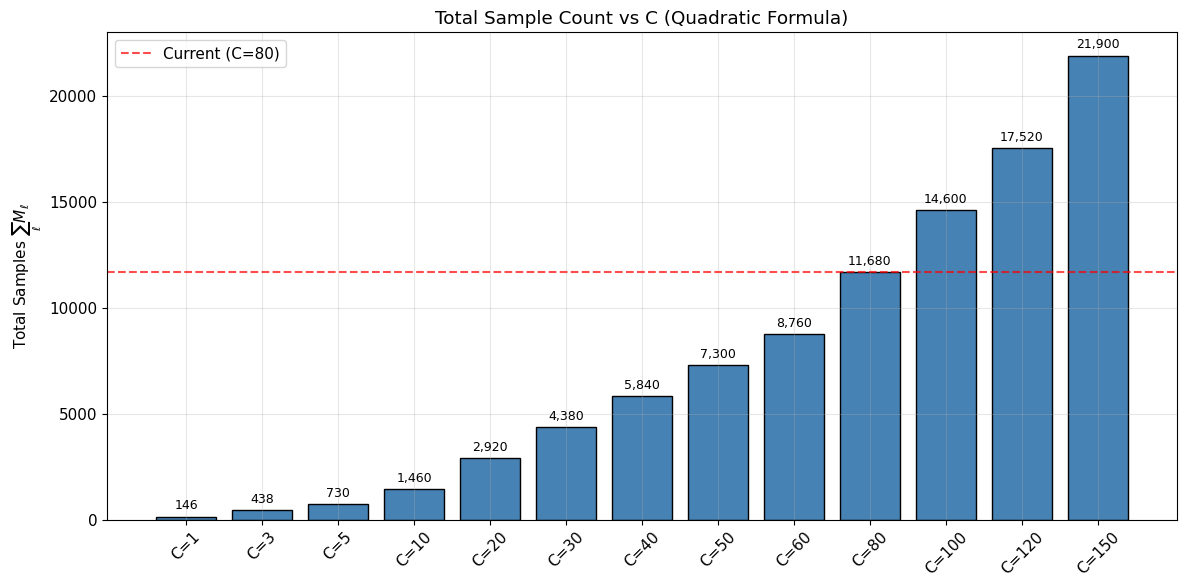

In [19]:
# Visualise sample counts
fig, ax = plt.subplots(figsize=(12, 6))

totals = [df_C_samples[df_C_samples['Strategy'] == f'C={C}']['Total'].values[0] for C in C_values]
bars = ax.bar(range(len(C_values)), totals, color='steelblue', edgecolor='black')
ax.set_xticks(range(len(C_values)))
ax.set_xticklabels([f'C={C}' for C in C_values], rotation=45)
ax.set_ylabel('Total Samples $\\sum_\\ell M_\\ell$')
ax.set_title('Total Sample Count vs C (Quadratic Formula)')

# Add value labels
for bar, total in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
            f'{total:,}', ha='center', va='bottom', fontsize=9)

# Mark current implementation
ax.axhline(y=totals[C_values.index(80)], color='red', linestyle='--', 
           label='Current (C=80)', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

### Run Experiments for Each $C$ Value

For each value of $C$, we run the MLMC estimation with 10 different random seeds.

In [21]:
print(f"Running {len(C_values)} C values × {N_SEEDS} seeds = {len(C_values) * N_SEEDS} total runs")
print(f"Cost profiling: {'ENABLED' if COST_METRICS_AVAILABLE else 'DISABLED'}")
print(f"Single-threaded: {DISABLE_THREADING}")
print("This may take a while...\n")

# Storage for results
results_by_C = {C: [] for C in C_values}

for C in C_values:
    print(f"Testing C = {C}...", end=" ")
    
    for seed_idx in range(N_SEEDS):
        seed = BASE_SEED + seed_idx
        
        result_dict = run_single_experiment(
            params=params,
            t_grid=t_grid,
            s_grid=s_grid,
            seed=seed,
            C=C,
            formula='quadratic',
            use_cost_profiler=COST_METRICS_AVAILABLE
        )
        results_by_C[C].append(result_dict)
        
        if not result_dict['success']:
            print(f"\n  Seed {seed}: FAILED - {result_dict.get('error', 'Unknown')[:50]}")
    
    # Summary for this C
    successes = sum(1 for r in results_by_C[C] if r['success'])
    if successes > 0:
        mean_time = np.mean([r['time'] for r in results_by_C[C] if r['success']])
        if COST_METRICS_AVAILABLE:
            mean_calls = np.mean([r['function_calls'] for r in results_by_C[C] if r['success'] and r['function_calls']])
            print(f"Success: {successes}/{N_SEEDS}, Mean time: {mean_time:.2f}s, Mean calls: {mean_calls:,.0f}")
        else:
            print(f"Success: {successes}/{N_SEEDS}, Mean time: {mean_time:.2f}s")
    else:
        print(f"Success: 0/{N_SEEDS}")

print("\n" + "="*60)
print("Part 1 experiments complete!")

Running 13 C values × 10 seeds = 130 total runs
Cost profiling: ENABLED
Single-threaded: True
This may take a while...

Testing C = 1... Success: 10/10, Mean time: 0.52s, Mean calls: 69,617
Testing C = 3... Success: 10/10, Mean time: 0.52s, Mean calls: 72,045
Testing C = 5... Success: 10/10, Mean time: 0.49s, Mean calls: 74,025
Testing C = 10... Success: 10/10, Mean time: 0.53s, Mean calls: 80,525
Testing C = 20... Success: 10/10, Mean time: 0.57s, Mean calls: 93,081
Testing C = 30... Success: 10/10, Mean time: 0.63s, Mean calls: 105,637
Testing C = 40... Success: 10/10, Mean time: 0.68s, Mean calls: 118,193
Testing C = 50... Success: 10/10, Mean time: 0.72s, Mean calls: 129,865
Testing C = 60... Success: 10/10, Mean time: 0.79s, Mean calls: 144,629
Testing C = 80... Success: 10/10, Mean time: 0.89s, Mean calls: 169,741
Testing C = 100... Success: 10/10, Mean time: 1.06s, Mean calls: 193,969
Testing C = 120... Success: 10/10, Mean time: 1.10s, Mean calls: 221,289
Testing C = 150... Suc

### Analyse Results: Varying $C$

In [22]:
# Build summary DataFrame with cost metrics
summary_data = []

for C in C_values:
    successful = [r for r in results_by_C[C] if r['success']]
    n_success = len(successful)
    
    if n_success > 0:
        # Basic metrics
        times = [r['time'] for r in successful]
        total_samples = successful[0]['total_samples']
        
        # Stability metrics
        centre_values = [r['b_squared'][len(t_grid)//2, len(s_grid)//2] for r in successful]
        
        row = {
            'C': C,
            'Total Samples': total_samples,
            'Success Rate': n_success / N_SEEDS,
            'Mean Time (s)': np.mean(times),
            'Std Time (s)': np.std(times),
            'Std b² (centre)': np.std(centre_values),
        }
        
        # Add cost metrics if available
        if COST_METRICS_AVAILABLE:
            cpu_times = [r['cpu_time'] for r in successful if r['cpu_time'] is not None]
            func_calls = [r['function_calls'] for r in successful if r['function_calls'] is not None]
            memory = [r['peak_memory_mb'] for r in successful if r['peak_memory_mb'] is not None]
            
            if cpu_times:
                row['Mean CPU (s)'] = np.mean(cpu_times)
            if func_calls:
                row['Mean Calls'] = int(np.mean(func_calls))
            if memory:
                row['Mean Memory (MB)'] = np.mean(memory)
        
        summary_data.append(row)
    else:
        row = {
            'C': C,
            'Total Samples': None,
            'Success Rate': 0.0,
            'Mean Time (s)': None,
            'Std Time (s)': None,
            'Std b² (centre)': None,
        }
        if COST_METRICS_AVAILABLE:
            row['Mean CPU (s)'] = None
            row['Mean Calls'] = None
            row['Mean Memory (MB)'] = None
        summary_data.append(row)

df_summary_C = pd.DataFrame(summary_data)

print("Summary of C Variation Experiments:")
print("=" * 90)
print(df_summary_C.to_string(index=False))

Summary of C Variation Experiments:
  C  Total Samples  Success Rate  Mean Time (s)  Std Time (s)  Std b² (centre)  Mean CPU (s)  Mean Calls  Mean Memory (MB)
  1            146           1.0       0.518819      0.029872        24.153361      0.501012       69617        109.884728
  3            438           1.0       0.520479      0.013279        15.095261      0.509911       72045        109.884732
  5            730           1.0       0.493918      0.019705        16.480266      0.490794       74025        109.884723
 10           1460           1.0       0.528202      0.017639        14.957786      0.525777       80525        109.884721
 20           2920           1.0       0.572687      0.010469         9.147239      0.571473       93081        109.884717
 30           4380           1.0       0.625232      0.021734        12.121763      0.623480      105637        109.884772
 40           5840           1.0       0.683552      0.017789        10.745874      0.681005      11819

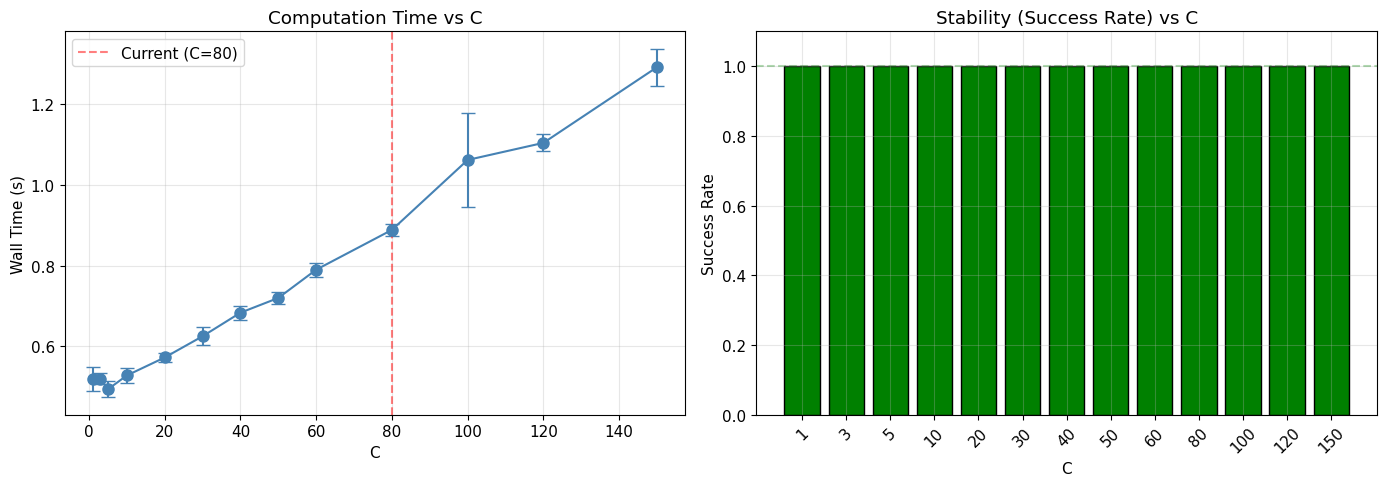

In [23]:
# Visualise results: Wall time and success rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wall time vs C
ax1 = axes[0]
valid_mask = df_summary_C['Mean Time (s)'].notna()
ax1.errorbar(
    df_summary_C.loc[valid_mask, 'C'],
    df_summary_C.loc[valid_mask, 'Mean Time (s)'],
    yerr=df_summary_C.loc[valid_mask, 'Std Time (s)'],
    fmt='o-', capsize=5, markersize=8, color='steelblue'
)
ax1.set_xlabel('C')
ax1.set_ylabel('Wall Time (s)')
ax1.set_title('Computation Time vs C')
ax1.axvline(x=80, color='red', linestyle='--', alpha=0.5, label='Current (C=80)')
ax1.legend()

# Success rate vs C
ax2 = axes[1]
colors = ['green' if sr == 1.0 else 'orange' if sr > 0.5 else 'red' 
          for sr in df_summary_C['Success Rate']]
ax2.bar(range(len(C_values)), df_summary_C['Success Rate'], color=colors, edgecolor='black')
ax2.set_xticks(range(len(C_values)))
ax2.set_xticklabels([str(C) for C in C_values], rotation=45)
ax2.set_xlabel('C')
ax2.set_ylabel('Success Rate')
ax2.set_title('Stability (Success Rate) vs C')
ax2.axhline(y=1.0, color='green', linestyle='--', alpha=0.3)
ax2.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

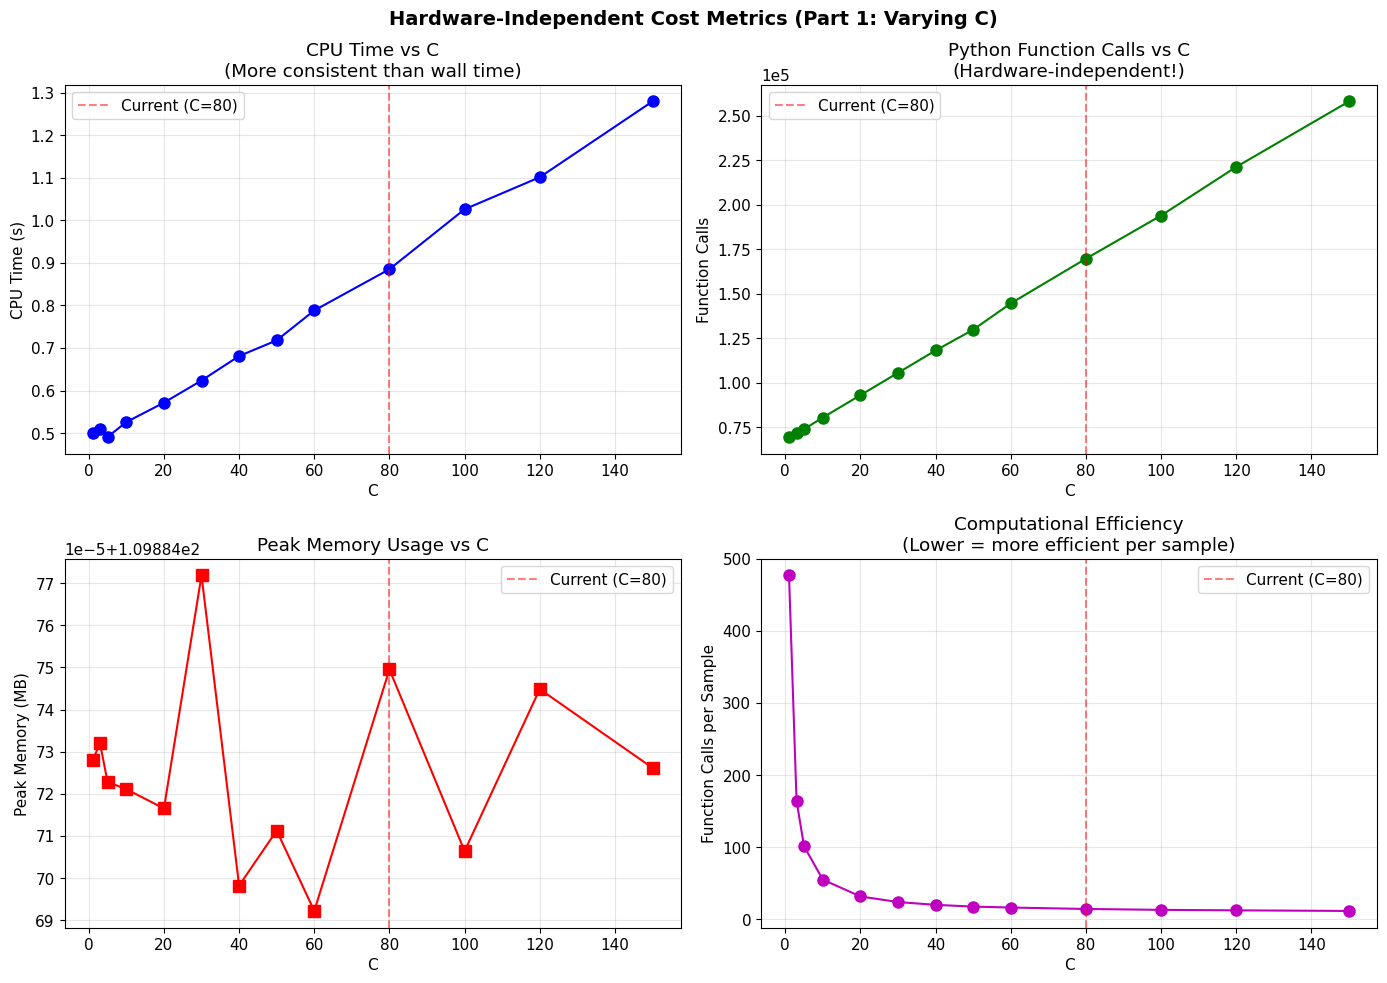

In [34]:
# NEW: Hardware-independent cost metrics visualisation
if COST_METRICS_AVAILABLE and 'Mean Calls' in df_summary_C.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    valid_mask = df_summary_C['Mean Calls'].notna()
    C_valid = df_summary_C.loc[valid_mask, 'C'].values
    
    # CPU Time vs C
    ax = axes[0, 0]
    ax.plot(C_valid, df_summary_C.loc[valid_mask, 'Mean CPU (s)'], 'bo-', markersize=8)
    ax.set_xlabel('C')
    ax.set_ylabel('CPU Time (s)')
    ax.set_title('CPU Time vs C\n(More consistent than wall time)')
    ax.axvline(x=80, color='red', linestyle='--', alpha=0.5, label='Current (C=80)')
    ax.legend()
    
    # Function calls vs C (hardware-independent!)
    ax = axes[0, 1]
    ax.plot(C_valid, df_summary_C.loc[valid_mask, 'Mean Calls'], 'go-', markersize=8)
    ax.set_xlabel('C')
    ax.set_ylabel('Function Calls')
    ax.set_title('Python Function Calls vs C\n(Hardware-independent!)')
    ax.axvline(x=80, color='red', linestyle='--', alpha=0.5, label='Current (C=80)')
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    ax.legend()
    
    # Peak memory vs C
    ax = axes[1, 0]
    ax.plot(C_valid, df_summary_C.loc[valid_mask, 'Mean Memory (MB)'], 'rs-', markersize=8)
    ax.set_xlabel('C')
    ax.set_ylabel('Peak Memory (MB)')
    ax.set_title('Peak Memory Usage vs C')
    ax.axvline(x=80, color='red', linestyle='--', alpha=0.5, label='Current (C=80)')
    ax.legend()
    
    # Cost per sample (efficiency metric)
    ax = axes[1, 1]
    samples = df_summary_C.loc[valid_mask, 'Total Samples'].values
    calls = df_summary_C.loc[valid_mask, 'Mean Calls'].values
    calls_per_sample = calls / samples
    ax.plot(C_valid, calls_per_sample, 'mo-', markersize=8)
    ax.set_xlabel('C')
    ax.set_ylabel('Function Calls per Sample')
    ax.set_title('Computational Efficiency\n(Lower = more efficient per sample)')
    ax.axvline(x=80, color='red', linestyle='--', alpha=0.5, label='Current (C=80)')
    ax.legend()
    
    fig.suptitle('Hardware-Independent Cost Metrics (Part 1: Varying C)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Cost metrics not available. Install cost_metrics.py for hardware-independent metrics.")

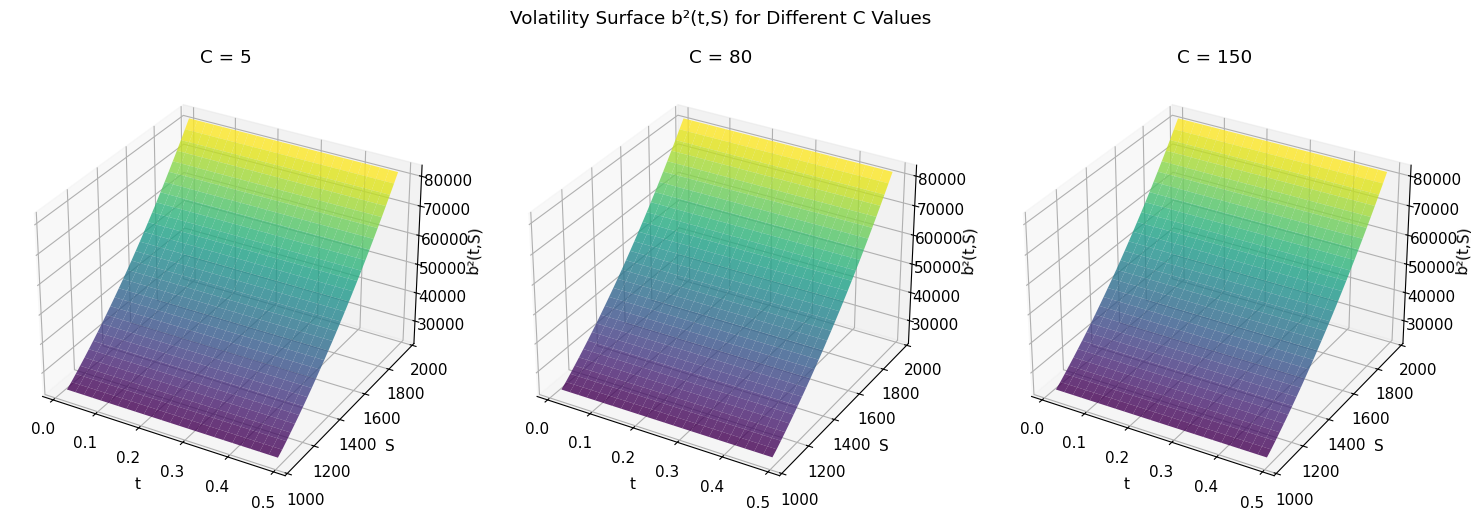

In [37]:
# Surface comparison: C=40 vs C=80 vs C=120
C_to_compare = [5, 80, 150]

fig = plt.figure(figsize=(15, 5))

for idx, C in enumerate(C_to_compare):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    
    successful_runs = [r for r in results_by_C[C] if r['success']]
    if len(successful_runs) > 0:
        mean_surface = np.mean([r['b_squared'] for r in successful_runs], axis=0)
        
        T_mesh, S_mesh = np.meshgrid(t_grid, s_grid, indexing='ij')
        surf = ax.plot_surface(T_mesh, S_mesh, mean_surface, cmap=cm.viridis, alpha=0.8)
        
        ax.set_xlabel('t')
        ax.set_ylabel('S')
        ax.set_zlabel('b²(t,S)')
        ax.set_title(f'C = {C}')
    else:
        ax.set_title(f'C = {C} (FAILED)')

plt.suptitle('Volatility Surface b²(t,S) for Different C Values', y=1.02)
plt.tight_layout()
plt.show()

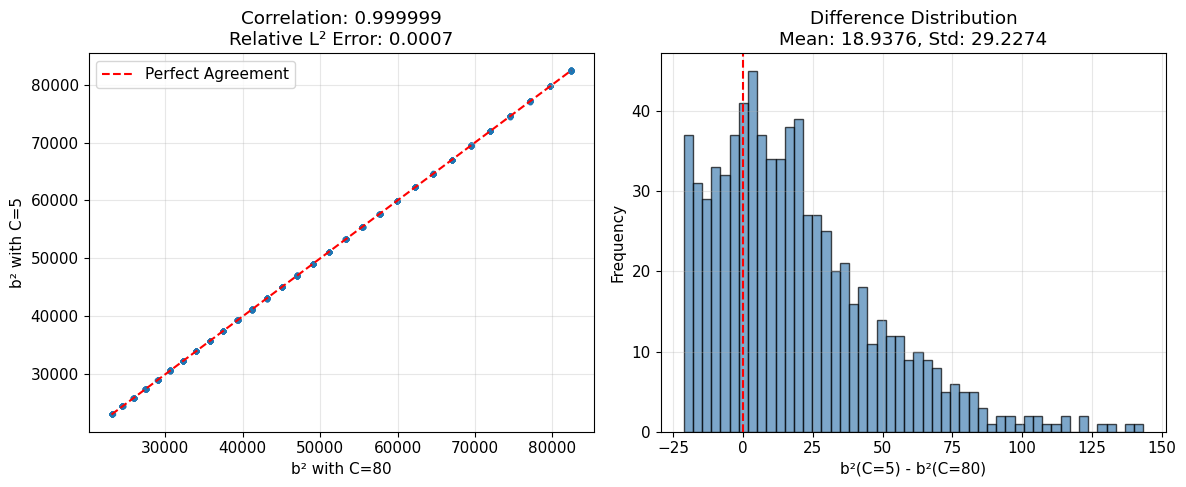

In [24]:
# Correlation plot: Compare surfaces for different C values
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

C_baseline = 80
C_test = 5

successful_baseline = [r for r in results_by_C[C_baseline] if r['success']]
successful_test = [r for r in results_by_C[C_test] if r['success']]

if len(successful_baseline) > 0 and len(successful_test) > 0:
    mean_baseline = np.mean([r['b_squared'] for r in successful_baseline], axis=0).flatten()
    mean_test = np.mean([r['b_squared'] for r in successful_test], axis=0).flatten()
    
    # Scatter plot
    ax1 = axes[0]
    ax1.scatter(mean_baseline, mean_test, alpha=0.5, s=10)
    
    lims = [min(mean_baseline.min(), mean_test.min()),
            max(mean_baseline.max(), mean_test.max())]
    ax1.plot(lims, lims, 'r--', label='Perfect Agreement')
    
    corr = np.corrcoef(mean_baseline, mean_test)[0, 1]
    l2_err = compute_l2_error(mean_test.reshape(-1), mean_baseline.reshape(-1))
    ax1.set_xlabel(f'b² with C={C_baseline}')
    ax1.set_ylabel(f'b² with C={C_test}')
    ax1.set_title(f'Correlation: {corr:.6f}\nRelative L² Error: {l2_err:.4f}')
    ax1.legend()
    
    # Difference histogram
    ax2 = axes[1]
    diff = mean_test - mean_baseline
    ax2.hist(diff, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--')
    ax2.set_xlabel(f'b²(C={C_test}) - b²(C={C_baseline})')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'Difference Distribution\nMean: {np.mean(diff):.4f}, Std: {np.std(diff):.4f}')
else:
    print(f"Cannot compare: C={C_baseline} has {len(successful_baseline)} successes, "
          f"C={C_test} has {len(successful_test)} successes")

plt.tight_layout()
plt.show()

### Part 1 Conclusions

Based on the above analysis:

- **Minimum stable C:** 10
- **Recommended C:** Not sure
- **Potential speedup vs C=80:** High

---

# Part 2: TRUE Comparison of Different Allocation Formulas

Now we compare fundamentally different formulas for $M_\ell$ using **properly modified MLMC functions**.

| Strategy | Formula | Theoretical Basis |
|----------|---------|-------------------|
| Quadratic | $M_\ell = C \cdot m^2$ | Conservative (our current) |
| Log | $M_\ell = C \cdot m \log(m+1)$ | Cohen-Migliorati optimal |
| Sqrt | $M_\ell = C \cdot m^{1.5}$ | Intermediate |
| Linear | $M_\ell = C \cdot m$ | Minimum for uniqueness |
| Log² | $M_\ell = C \cdot m \log^2(m+1)$ | Extra conservative relative to log |

In [27]:
# Define formulas to test
formulas_to_test = ['quadratic', 'log', 'sqrt', 'linear', 'log_squared']
C_fixed = 5  # Keep C fixed to isolate formula effect

print(f"Testing {len(formulas_to_test)} different allocation formulas with C={C_fixed}")
print("\nSample counts by formula:")
print("=" * 90)

formula_strategies = {
    'Quadratic (C·m²)': (C_fixed, 'quadratic'),
    'Log (C·m·log(m+1))': (C_fixed, 'log'),
    'Sqrt (C·m^1.5)': (C_fixed, 'sqrt'),
    'Linear (C·m)': (C_fixed, 'linear'),
    'Log² (C·m·log²(m+1))': (C_fixed, 'log_squared'),
}

df_formula_samples = format_samples_table(params.max_degree, formula_strategies)
print(df_formula_samples.to_string(index=False))

Testing 5 different allocation formulas with C=5

Sample counts by formula:
            Strategy  C     Formula  Level 0  Level 1  Level 2  Level 3  Total
    Quadratic (C·m²)  5   quadratic      500      180       45        5    730
  Log (C·m·log(m+1))  5         log      119       58       20        5    202
      Sqrt (C·m^1.5)  5        sqrt      158       73       25        5    261
        Linear (C·m)  5      linear       50       30       15        5    100
Log² (C·m·log²(m+1))  5 log_squared      287      113       28        5    433


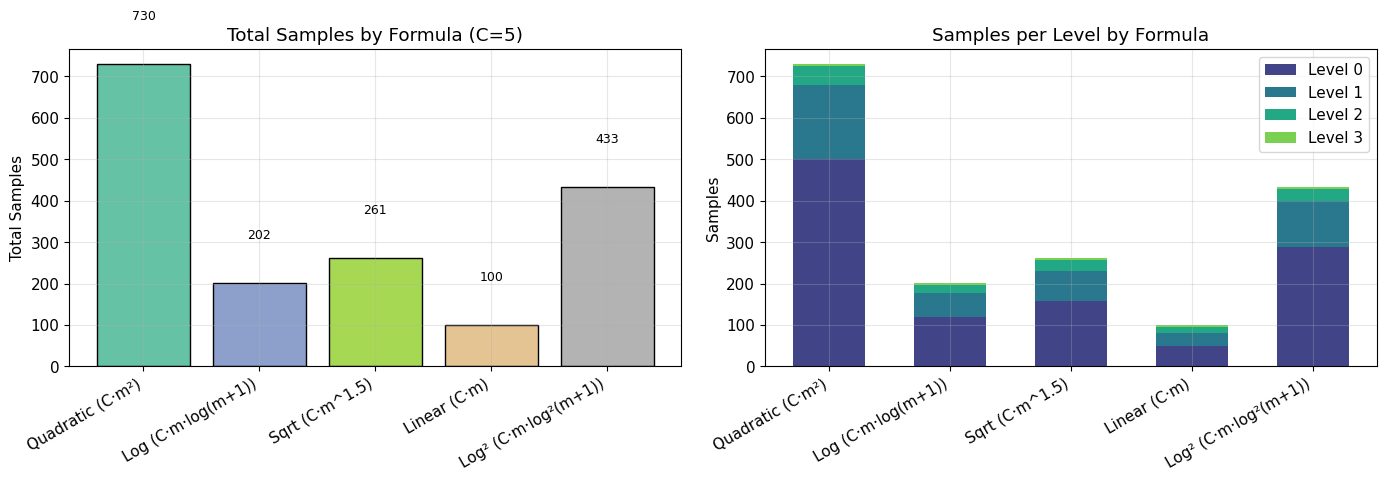

In [26]:
# Visualise sample counts by formula
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: total samples
ax1 = axes[0]
formula_names = list(formula_strategies.keys())
totals = df_formula_samples['Total'].values
colors = plt.cm.Set2(np.linspace(0, 1, len(formula_names)))
bars = ax1.bar(range(len(formula_names)), totals, color=colors, edgecolor='black')
ax1.set_xticks(range(len(formula_names)))
ax1.set_xticklabels(formula_names, rotation=30, ha='right')
ax1.set_ylabel('Total Samples')
ax1.set_title(f'Total Samples by Formula (C={C_fixed})')

for bar, total in zip(bars, totals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{total:,}', ha='center', va='bottom', fontsize=9)

# Stacked bar: samples per level
ax2 = axes[1]
x = np.arange(len(formula_names))
width = 0.6

bottom = np.zeros(len(formula_names))
level_colors = plt.cm.viridis(np.linspace(0.2, 0.8, params.max_degree + 1))

for l in range(params.max_degree + 1):
    values = df_formula_samples[f'Level {l}'].values
    ax2.bar(x, values, width, bottom=bottom, label=f'Level {l}', color=level_colors[l])
    bottom += values

ax2.set_xticks(x)
ax2.set_xticklabels(formula_names, rotation=30, ha='right')
ax2.set_ylabel('Samples')
ax2.set_title('Samples per Level by Formula')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Run TRUE Formula Comparison Experiments

Using the modified MLMC functions with proper sample allocation for each formula.

In [28]:
print(f"Running TRUE formula comparison: {len(formulas_to_test)} formulas × {N_SEEDS} seeds")
print(f"= {len(formulas_to_test) * N_SEEDS} total runs")
print(f"Cost profiling: {'ENABLED' if COST_METRICS_AVAILABLE else 'DISABLED'}")
print(f"Single-threaded: {DISABLE_THREADING}\n")

results_by_formula = {f: [] for f in formulas_to_test}

for formula in formulas_to_test:
    samples_info = compute_samples_for_formula(params.max_degree, C_fixed, formula)
    total_samples = sum(samples_info.values())
    print(f"Testing formula: {formula} ({total_samples:,} total samples)...", end=" ")
    
    for seed_idx in range(N_SEEDS):
        seed = BASE_SEED + seed_idx
        
        result_dict = run_single_experiment(
            params=params,
            t_grid=t_grid,
            s_grid=s_grid,
            seed=seed,
            C=C_fixed,
            formula=formula,
            use_cost_profiler=COST_METRICS_AVAILABLE
        )
        results_by_formula[formula].append(result_dict)
        
        if not result_dict['success']:
            print(f"\n  Seed {seed}: FAILED - {result_dict.get('error', 'Unknown')[:50]}")
    
    # Summary for this formula
    successes = sum(1 for r in results_by_formula[formula] if r['success'])
    if successes > 0:
        mean_time = np.mean([r['time'] for r in results_by_formula[formula] if r['success']])
        if COST_METRICS_AVAILABLE:
            mean_calls = np.mean([r['function_calls'] for r in results_by_formula[formula] 
                                  if r['success'] and r['function_calls']])
            print(f"Success: {successes}/{N_SEEDS}, Mean time: {mean_time:.2f}s, Mean calls: {mean_calls:,.0f}")
        else:
            print(f"Success: {successes}/{N_SEEDS}, Mean time: {mean_time:.2f}s")
    else:
        print(f"Success: 0/{N_SEEDS}")

print("\n" + "="*60)
print("Part 2 experiments complete!")

Running TRUE formula comparison: 5 formulas × 10 seeds
= 50 total runs
Cost profiling: ENABLED
Single-threaded: True

Testing formula: quadratic (730 total samples)... Success: 10/10, Mean time: 0.50s, Mean calls: 74,025
Testing formula: log (202 total samples)... Success: 10/10, Mean time: 0.50s, Mean calls: 70,449
Testing formula: sqrt (261 total samples)... Success: 10/10, Mean time: 0.50s, Mean calls: 70,833
Testing formula: linear (100 total samples)... Success: 10/10, Mean time: 0.48s, Mean calls: 69,237
Testing formula: log_squared (433 total samples)... Success: 10/10, Mean time: 0.50s, Mean calls: 72,045

Part 2 experiments complete!


### Analyse Results: Formula Comparison

In [29]:
# Build summary DataFrame with cost metrics
summary_data_formula = []

for formula in formulas_to_test:
    successful = [r for r in results_by_formula[formula] if r['success']]
    n_success = len(successful)
    
    if n_success > 0:
        times = [r['time'] for r in successful]
        total_samples = successful[0]['total_samples']
        
        # Stability metrics
        all_b_squared = np.array([r['b_squared'] for r in successful])
        std_b_squared = np.std(all_b_squared, axis=0)
        
        row = {
            'Formula': formula,
            'Total Samples': total_samples,
            'Success Rate': n_success / N_SEEDS,
            'Mean Time (s)': np.mean(times),
            'Std Time (s)': np.std(times),
            'Mean Std(b²)': np.mean(std_b_squared),
            'Max Std(b²)': np.max(std_b_squared),
        }
        
        # Add cost metrics if available
        if COST_METRICS_AVAILABLE:
            cpu_times = [r['cpu_time'] for r in successful if r['cpu_time'] is not None]
            func_calls = [r['function_calls'] for r in successful if r['function_calls'] is not None]
            memory = [r['peak_memory_mb'] for r in successful if r['peak_memory_mb'] is not None]
            
            if cpu_times:
                row['Mean CPU (s)'] = np.mean(cpu_times)
            if func_calls:
                row['Mean Calls'] = int(np.mean(func_calls))
            if memory:
                row['Mean Memory (MB)'] = np.mean(memory)
        
        summary_data_formula.append(row)
    else:
        row = {
            'Formula': formula,
            'Total Samples': None,
            'Success Rate': 0.0,
            'Mean Time (s)': None,
            'Std Time (s)': None,
            'Mean Std(b²)': None,
            'Max Std(b²)': None,
        }
        if COST_METRICS_AVAILABLE:
            row['Mean CPU (s)'] = None
            row['Mean Calls'] = None
            row['Mean Memory (MB)'] = None
        summary_data_formula.append(row)

df_summary_formula = pd.DataFrame(summary_data_formula)

print("Summary of Formula Comparison Experiments:")
print("=" * 100)
print(df_summary_formula.to_string(index=False))

Summary of Formula Comparison Experiments:
    Formula  Total Samples  Success Rate  Mean Time (s)  Std Time (s)  Mean Std(b²)  Max Std(b²)  Mean CPU (s)  Mean Calls  Mean Memory (MB)
  quadratic            730           1.0       0.500975      0.015153     77.686131   409.884379      0.496308       74025        109.884711
        log            202           1.0       0.498690      0.008900    155.214168   813.382328      0.493410       70449        109.884765
       sqrt            261           1.0       0.496465      0.005387    134.363359   725.659474      0.492811       70833        109.884747
     linear            100           1.0       0.477144      0.018265    253.028395  1394.853615      0.474128       69237        109.884828
log_squared            433           1.0       0.504253      0.013902    104.492973   512.833585      0.498223       72045        109.884725


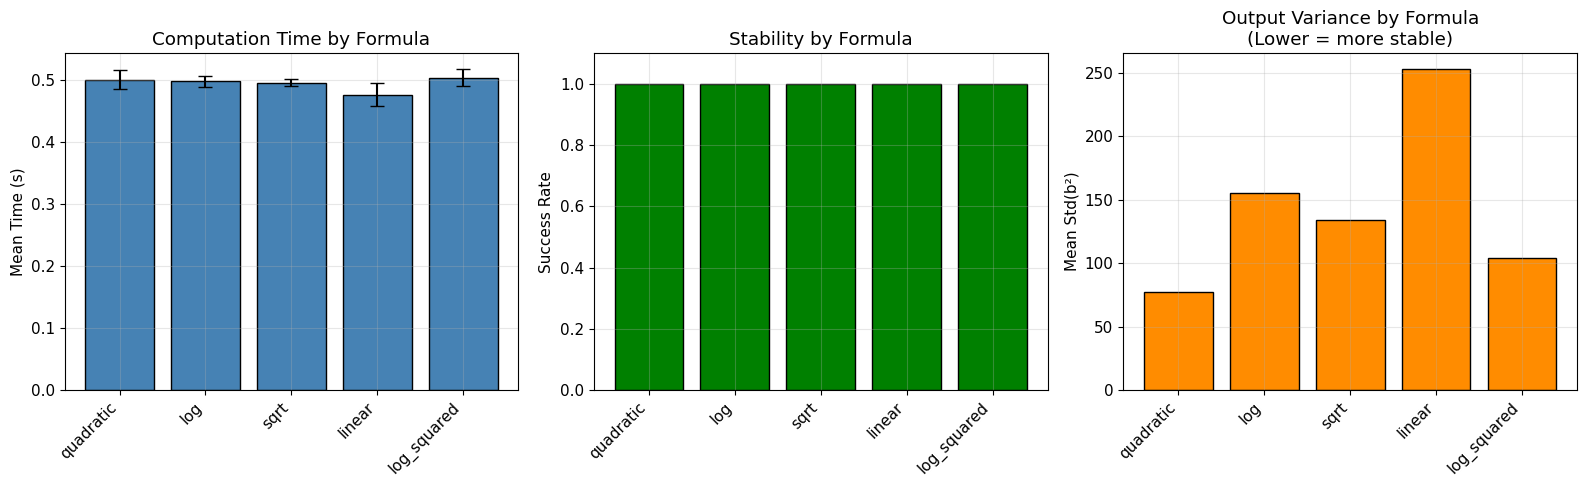

In [30]:
# Visualise: Time and stability by formula
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

valid_formulas = df_summary_formula[df_summary_formula['Success Rate'] > 0]['Formula'].values
x = np.arange(len(valid_formulas))

# Wall time
ax1 = axes[0]
times = df_summary_formula[df_summary_formula['Success Rate'] > 0]['Mean Time (s)'].values
time_std = df_summary_formula[df_summary_formula['Success Rate'] > 0]['Std Time (s)'].values
bars = ax1.bar(x, times, yerr=time_std, capsize=5, color='steelblue', edgecolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(valid_formulas, rotation=45, ha='right')
ax1.set_ylabel('Mean Time (s)')
ax1.set_title('Computation Time by Formula')

# Success rate
ax2 = axes[1]
success_rates = df_summary_formula[df_summary_formula['Success Rate'] > 0]['Success Rate'].values
colors = ['green' if sr == 1.0 else 'orange' if sr > 0.5 else 'red' for sr in success_rates]
ax2.bar(x, success_rates, color=colors, edgecolor='black')
ax2.set_xticks(x)
ax2.set_xticklabels(valid_formulas, rotation=45, ha='right')
ax2.set_ylabel('Success Rate')
ax2.set_title('Stability by Formula')
ax2.set_ylim([0, 1.1])

# Variance (stability)
ax3 = axes[2]
mean_std = df_summary_formula[df_summary_formula['Success Rate'] > 0]['Mean Std(b²)'].values
ax3.bar(x, mean_std, color='darkorange', edgecolor='black')
ax3.set_xticks(x)
ax3.set_xticklabels(valid_formulas, rotation=45, ha='right')
ax3.set_ylabel('Mean Std(b²)')
ax3.set_title('Output Variance by Formula\n(Lower = more stable)')

plt.tight_layout()
plt.show()

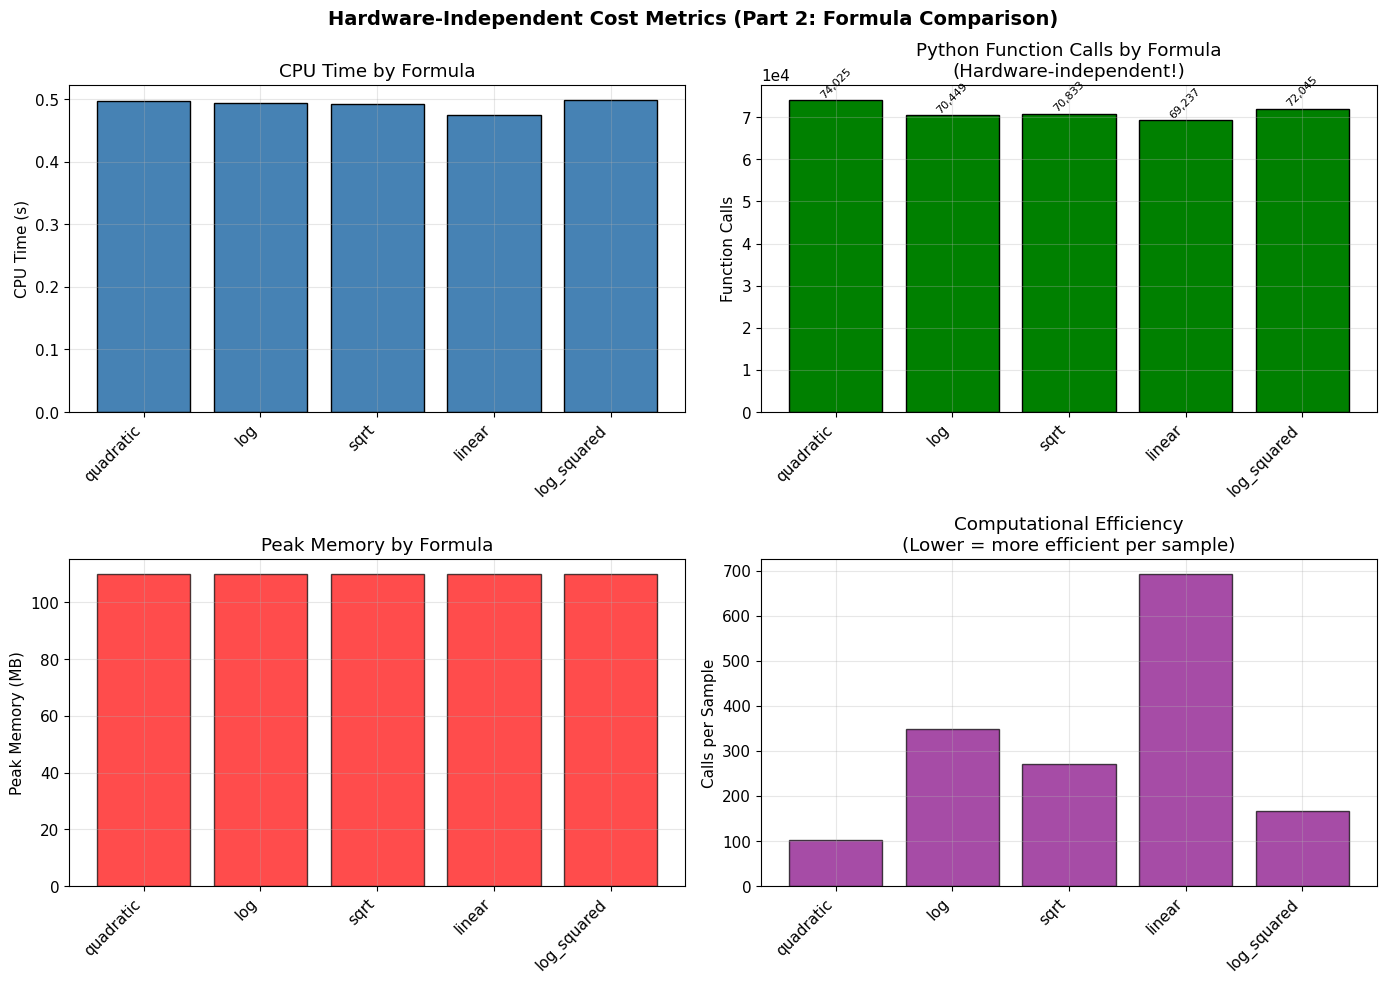

In [31]:
# NEW: Hardware-independent cost metrics for formula comparison
if COST_METRICS_AVAILABLE and 'Mean Calls' in df_summary_formula.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    valid_df = df_summary_formula[df_summary_formula['Mean Calls'].notna()]
    x = np.arange(len(valid_df))
    formulas_valid = valid_df['Formula'].values
    
    # CPU Time
    ax = axes[0, 0]
    ax.bar(x, valid_df['Mean CPU (s)'], color='steelblue', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(formulas_valid, rotation=45, ha='right')
    ax.set_ylabel('CPU Time (s)')
    ax.set_title('CPU Time by Formula')
    
    # Function calls (hardware-independent!)
    ax = axes[0, 1]
    bars = ax.bar(x, valid_df['Mean Calls'], color='green', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(formulas_valid, rotation=45, ha='right')
    ax.set_ylabel('Function Calls')
    ax.set_title('Python Function Calls by Formula\n(Hardware-independent!)')
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # Add value labels
    for bar, val in zip(bars, valid_df['Mean Calls']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,.0f}', ha='center', va='bottom', fontsize=8, rotation=45)
    
    # Peak memory
    ax = axes[1, 0]
    ax.bar(x, valid_df['Mean Memory (MB)'], color='red', edgecolor='black', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(formulas_valid, rotation=45, ha='right')
    ax.set_ylabel('Peak Memory (MB)')
    ax.set_title('Peak Memory by Formula')
    
    # Efficiency: Calls per sample
    ax = axes[1, 1]
    calls_per_sample = valid_df['Mean Calls'] / valid_df['Total Samples']
    ax.bar(x, calls_per_sample, color='purple', edgecolor='black', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(formulas_valid, rotation=45, ha='right')
    ax.set_ylabel('Calls per Sample')
    ax.set_title('Computational Efficiency\n(Lower = more efficient per sample)')
    
    fig.suptitle('Hardware-Independent Cost Metrics (Part 2: Formula Comparison)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Cost metrics not available. Install cost_metrics.py for hardware-independent metrics.")

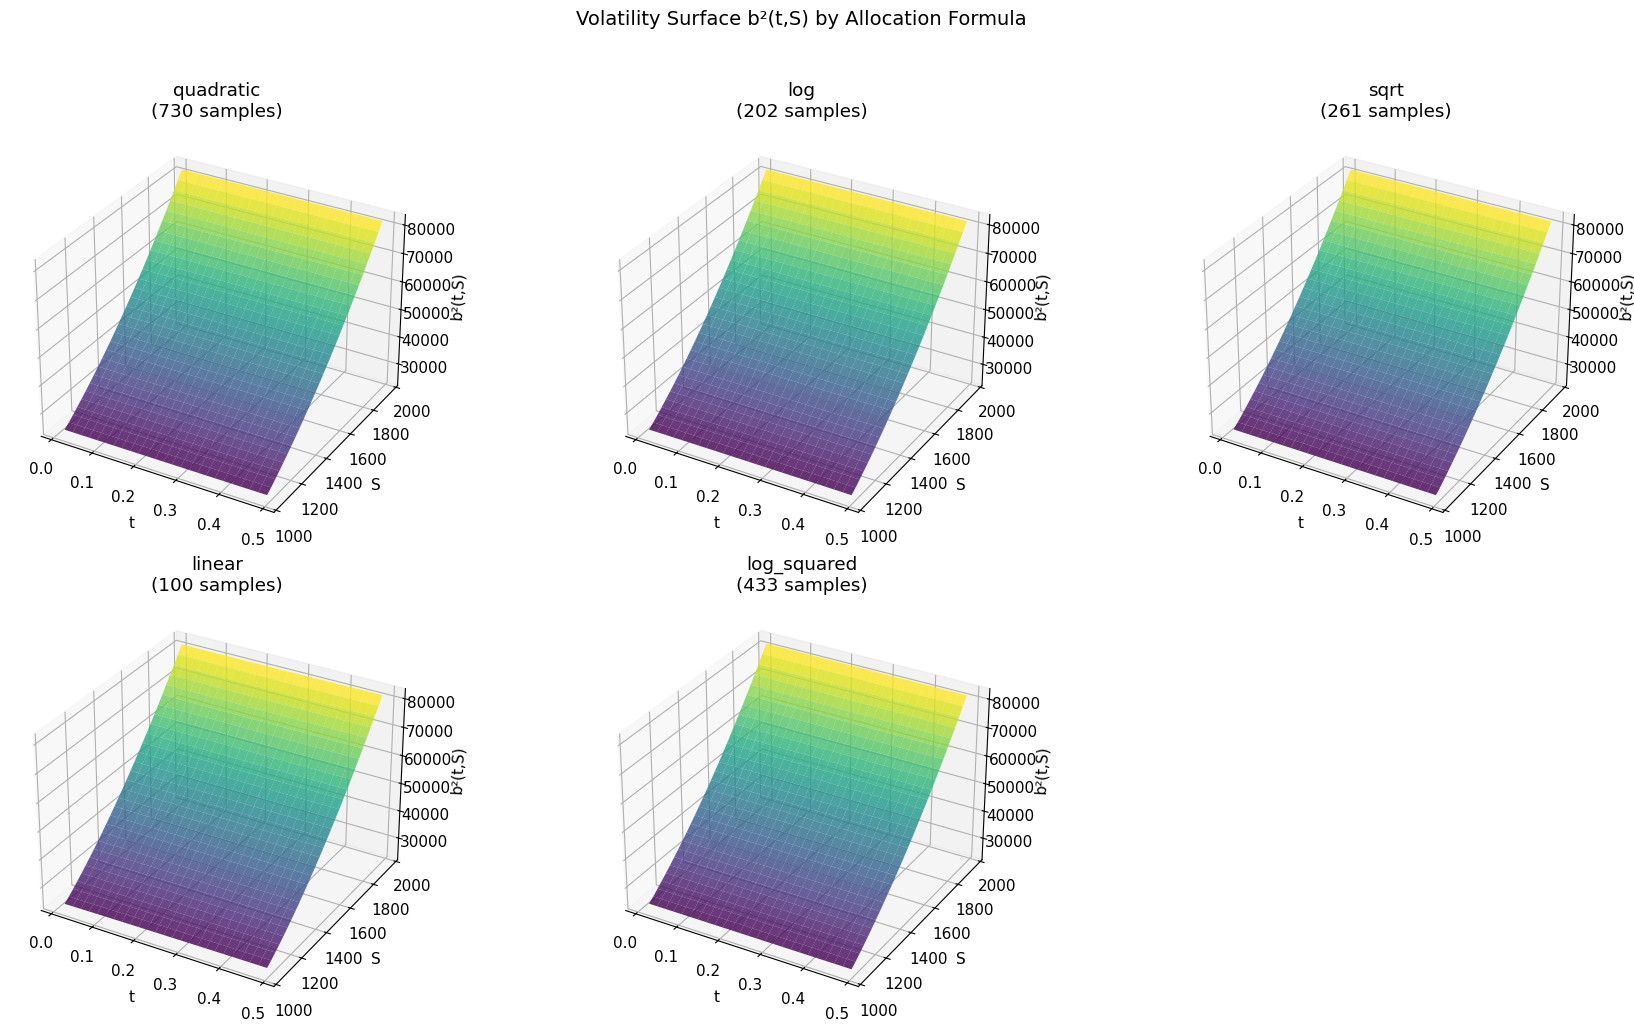

In [32]:
# Side-by-side 3D surface comparison
successful_formulas = [f for f in formulas_to_test 
                       if any(r['success'] for r in results_by_formula[f])]

n_cols = min(3, len(successful_formulas))
n_rows = (len(successful_formulas) + n_cols - 1) // n_cols

fig = plt.figure(figsize=(6 * n_cols, 5 * n_rows))

for idx, formula in enumerate(successful_formulas):
    ax = fig.add_subplot(n_rows, n_cols, idx + 1, projection='3d')
    
    successful = [r for r in results_by_formula[formula] if r['success']]
    mean_surface = np.mean([r['b_squared'] for r in successful], axis=0)
    total_samples = successful[0]['total_samples']
    
    T_mesh, S_mesh = np.meshgrid(t_grid, s_grid, indexing='ij')
    surf = ax.plot_surface(T_mesh, S_mesh, mean_surface, cmap=cm.viridis, alpha=0.8)
    
    ax.set_xlabel('t')
    ax.set_ylabel('S')
    ax.set_zlabel('b²(t,S)')
    ax.set_title(f'{formula}\n({total_samples:,} samples)')

plt.suptitle('Volatility Surface b²(t,S) by Allocation Formula', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

---

## Final Summary and Recommendations

In [33]:
print("="*90)
print("FINAL SUMMARY")
print("="*90)

print(f"\nBenchmark Configuration:")
print(f"  Threading disabled: {DISABLE_THREADING}")
print(f"  Cost metrics available: {COST_METRICS_AVAILABLE}")

print("\n--- Part 1: Varying C in Quadratic Formula ---")
cols_to_show = ['C', 'Total Samples', 'Success Rate', 'Mean Time (s)', 'Std b² (centre)']
if COST_METRICS_AVAILABLE and 'Mean Calls' in df_summary_C.columns:
    cols_to_show.extend(['Mean CPU (s)', 'Mean Calls'])
print(df_summary_C[[c for c in cols_to_show if c in df_summary_C.columns]].to_string(index=False))

print("\n--- Part 2: TRUE Formula Comparison ---")
cols_to_show = ['Formula', 'Total Samples', 'Success Rate', 'Mean Time (s)', 'Std Time (s)', 'Mean Std(b²)', 'Max Std(b²)']
if COST_METRICS_AVAILABLE and 'Mean Calls' in df_summary_formula.columns:
    cols_to_show.extend(['Mean CPU (s)', 'Mean Calls'])
print(df_summary_formula[[c for c in cols_to_show if c in df_summary_formula.columns]].to_string(index=False))

print("\n" + "="*90)
print("KEY FINDINGS")
print("="*90)

# Find minimum stable C
stable_C_mask = df_summary_C['Success Rate'] == 1.0
if stable_C_mask.any():
    stable_C = df_summary_C.loc[stable_C_mask, 'C'].min()
    print(f"\n1. Minimum C with 100% success rate (quadratic): C = {stable_C}")
    
    if stable_C < 80:
        time_80 = df_summary_C[df_summary_C['C'] == 80]['Mean Time (s)'].values[0]
        time_min = df_summary_C[df_summary_C['C'] == stable_C]['Mean Time (s)'].values[0]
        speedup = time_80 / time_min
        print(f"   Potential speedup from C=80 to C={stable_C}: {speedup:.2f}x")
        
        if COST_METRICS_AVAILABLE and 'Mean Calls' in df_summary_C.columns:
            calls_80 = df_summary_C[df_summary_C['C'] == 80]['Mean Calls'].values[0]
            calls_min = df_summary_C[df_summary_C['C'] == stable_C]['Mean Calls'].values[0]
            if calls_80 and calls_min:
                call_reduction = calls_80 / calls_min
                print(f"   Function call reduction: {call_reduction:.2f}x (hardware-independent)")
else:
    print("\n1. No C value achieved 100% success rate")

# Best formula analysis
stable_formulas = df_summary_formula[df_summary_formula['Success Rate'] == 1.0]
if len(stable_formulas) > 0:
    fastest = stable_formulas.loc[stable_formulas['Mean Time (s)'].idxmin()]
    print(f"\n2. Fastest stable formula: {fastest['Formula']}")
    print(f"   Total samples: {fastest['Total Samples']:,}")
    print(f"   Mean time: {fastest['Mean Time (s)']:.2f}s")
    
    if COST_METRICS_AVAILABLE and 'Mean Calls' in df_summary_formula.columns:
        print(f"   Mean function calls: {fastest['Mean Calls']:,}")
    
    if fastest['Formula'] != 'quadratic':
        quad_time = df_summary_formula[df_summary_formula['Formula'] == 'quadratic']['Mean Time (s)'].values
        if len(quad_time) > 0 and not np.isnan(quad_time[0]):
            speedup = quad_time[0] / fastest['Mean Time (s)']
            print(f"   Speedup vs quadratic: {speedup:.2f}x")

print("\n" + "="*90)

FINAL SUMMARY

Benchmark Configuration:
  Threading disabled: True
  Cost metrics available: True

--- Part 1: Varying C in Quadratic Formula ---
  C  Total Samples  Success Rate  Mean Time (s)  Std b² (centre)  Mean CPU (s)  Mean Calls
  1            146           1.0       0.518819        24.153361      0.501012       69617
  3            438           1.0       0.520479        15.095261      0.509911       72045
  5            730           1.0       0.493918        16.480266      0.490794       74025
 10           1460           1.0       0.528202        14.957786      0.525777       80525
 20           2920           1.0       0.572687         9.147239      0.571473       93081
 30           4380           1.0       0.625232        12.121763      0.623480      105637
 40           5840           1.0       0.683552        10.745874      0.681005      118193
 50           7300           1.0       0.720059         7.622805      0.717913      129865
 60           8760           1.0   

## Conclusions

TO BE FILLED IN. I WANT TO AT LEAST SEE SOME COLLAPSE BEFORE I DO

### Part 1: Effect of C

- **Minimum stable C:** _____
- **Recommended C:** _____
- **Potential speedup:** _____

### Part 2: TRUE Formula Comparison

- **Quadratic stability:** _____
- **Log formula stability:** _____
- **Sqrt formula stability:** _____
- **Linear formula stability:** _____
- **Best trade-off (stability + speed):** _____

### Recommendations

1. If _____ formula is stable, consider switching from quadratic
2. Potential computational savings: _____
3. Further investigation needed: _____